Label order: ['positive', 'neutral', 'negative']
[Device] cuda
GPU: NVIDIA GeForce RTX 2080 Ti
Raw confusion matrix:
 [[ 85  37  23]
 [ 40 117  36]
 [ 14  41  96]]


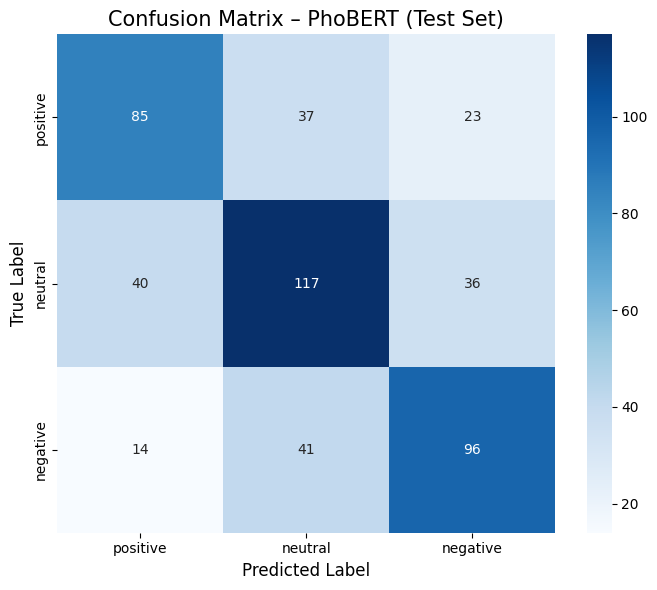

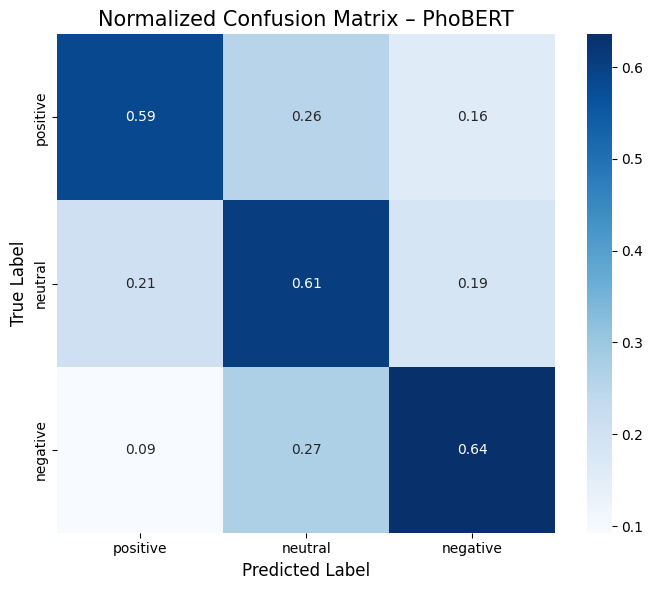

In [7]:
import json
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report

# =============================
# 1) Load test data
# =============================
test = pd.read_json("../.././test-preprocessed.json")
X_test = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)

# =============================
# 2) Load label maps
# =============================
with open("../.././phobert-ft-final/label_maps.json", "r", encoding="utf-8") as f:
    maps = json.load(f)
label2id = maps["label2id"]
id2label = {int(k): v for k, v in maps["id2label"].items()}
labels_sorted = [id2label[i] for i in sorted(id2label.keys())]

print("Label order:", labels_sorted)

# Encode nhãn test
y_test = np.array([label2id[x] for x in y_test_text])

# =============================
# 3) Load tokenizer + model
# =============================
tokenizer = AutoTokenizer.from_pretrained("../.././phobert-ft-final", use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained("../.././phobert-ft-final")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("[Device]", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =============================
# 4) Word segmentation using underthesea
# =============================
from underthesea import word_tokenize

preds = []

for text in X_test:
    # Word segmentation
    seg = word_tokenize(text, format="text")   # chuỗi dạng "tách từ"
    
    # Tokenize cho PhoBERT
    inputs = tokenizer(
        seg,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    ).to(device)

    # Predict
    with torch.no_grad():
        logits = model(**inputs).logits
        pred_id = torch.argmax(logits, dim=1).item()

    preds.append(pred_id)

preds = np.array(preds)

# =============================
# 5) Confusion Matrix
# =============================
cm = confusion_matrix(y_test, preds)
print("Raw confusion matrix:\n", cm)

# =============================
# 6) VẼ CONFUSION MATRIX ĐẸP
# =============================
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Confusion Matrix – PhoBERT (Test Set)", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

# =============================
# 7) Bản chuẩn hoá (optional)
# =============================
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Normalized Confusion Matrix – PhoBERT", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()
